# Phase 3 — Task 1: PyTorch Fundamentals

**Prepared by:** Madawi Alshebil  
**Email:** Madawi.alshebil@gmail.com  
**Supervisor:** Dr. Safwan Al-Selwi  
**Email:** saf1.alselwi@gmail.com

## Purpose
This notebook introduces the core PyTorch concepts required in Phase 3 Task 1:

- environment verification and device selection,
- tensor creation and common tensor operations,
- shapes, indexing, reshaping, and broadcasting,
- computational graphs and automatic differentiation (Autograd),
- custom `Dataset` and `DataLoader` classes,
- a complete beginner-level workflow using the Breast Cancer Wisconsin dataset from Phase 2.

The final section trains a small PyTorch binary classifier only to demonstrate the full workflow from **data loading → model → loss → optimizer → training → evaluation**.

## 1. Installation and environment

For Google Colab, PyTorch is normally preinstalled. For a local environment, use the official PyTorch installation selector:

- https://pytorch.org/get-started/locally/

A common CPU installation command is:

```bash
pip install torch torchvision torchaudio
```

Run the following cell to verify the installation and select the available device.

In [ ]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, Dataset

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

print("PyTorch version:", torch.__version__)
print("Selected device:", DEVICE)


PyTorch version: 2.10.0+cpu
Selected device: cpu


## 2. Tensors

A **tensor** is a multidimensional array. PyTorch uses tensors to represent:

- model inputs,
- model outputs,
- model parameters,
- gradients calculated during training.

The number of dimensions is commonly called the tensor's **rank**:

- scalar: 0 dimensions,
- vector: 1 dimension,
- matrix: 2 dimensions,
- higher-dimensional tensor: 3 or more dimensions.

In [ ]:
# Create tensors from Python data
scalar = torch.tensor(7)
vector = torch.tensor([1.0, 2.0, 3.0])
matrix = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

# Create tensors with built-in functions
zeros = torch.zeros((2, 3))
ones = torch.ones((2, 3))
random_tensor = torch.rand((2, 3))

print("Scalar:", scalar, "| shape:", scalar.shape)
print("Vector:", vector, "| shape:", vector.shape)
print("Matrix:")
print(matrix, "| shape:", matrix.shape)
print("Zeros:")
print(zeros)
print("Ones:")
print(ones)
print("Random tensor:")
print(random_tensor)


Scalar: tensor(7) | shape: torch.Size([])
Vector: tensor([1., 2., 3.]) | shape: torch.Size([3])
Matrix:
tensor([[1., 2.],
        [3., 4.]]) | shape: torch.Size([2, 2])
Zeros:
tensor([[0., 0., 0.],
        [0., 0., 0.]])
Ones:
tensor([[1., 1., 1.],
        [1., 1., 1.]])
Random tensor:
tensor([[0.8823, 0.9150, 0.3829],
        [0.9593, 0.3904, 0.6009]])


## 3. Common tensor operations

Tensor operations work similarly to NumPy operations. Common examples include:

- element-wise addition and multiplication,
- matrix multiplication,
- indexing and slicing,
- reshaping,
- moving tensors between devices,
- converting between NumPy arrays and tensors.

In [ ]:
a = torch.tensor([
    [1.0, 2.0],
    [3.0, 4.0]
])

b = torch.tensor([
    [5.0, 6.0],
    [7.0, 8.0]
])

print("Element-wise addition:")
print(a + b)
print("Element-wise multiplication:")
print(a * b)
print("Matrix multiplication:")
print(a @ b)
print("First row:", a[0])
print("Second column:", a[:, 1])


Element-wise addition:
tensor([[ 6.,  8.],
        [10., 12.]])
Element-wise multiplication:
tensor([[ 5., 12.],
        [21., 32.]])
Matrix multiplication:
tensor([[19., 22.],
        [43., 50.]])
First row: tensor([1., 2.])
Second column: tensor([2., 4.])


## 4. Shapes, reshaping, and broadcasting

- `shape` describes the size of every tensor dimension.
- `reshape()` changes the tensor arrangement without changing its values.
- **Broadcasting** allows PyTorch to combine compatible tensors of different shapes automatically.

In [ ]:
numbers = torch.arange(1, 7)
reshaped = numbers.reshape(2, 3)

row_offsets = torch.tensor([10, 20, 30])
broadcast_result = reshaped + row_offsets

print("Original tensor:", numbers)
print("Reshaped tensor:")
print(reshaped)
print("Broadcasting result:")
print(broadcast_result)


Original tensor: tensor([1, 2, 3, 4, 5, 6])
Reshaped tensor:
tensor([[1, 2, 3],
        [4, 5, 6]])
Broadcasting result:
tensor([[11, 22, 33],
        [14, 25, 36]])


## 5. Computational graphs and Autograd

During the forward pass, PyTorch records tensor operations in a **computational graph**. When `backward()` is called, Autograd follows this graph in reverse and calculates gradients using the chain rule.

A tensor must use `requires_grad=True` when its gradient should be tracked.

In [ ]:
x = torch.tensor(3.0, requires_grad=True)
y = x**2 + 2*x + 1

y.backward()

print("x =", x.item())
print("y = x² + 2x + 1 =", y.item())
print("dy/dx at x = 3:", x.grad.item())


x = 3.0
y = x² + 2x + 1 = 16.0
dy/dx at x = 3: 8.0


For \(y=x^2+2x+1\), the derivative is \(\frac{dy}{dx}=2x+2\). At \(x=3\), the gradient is \(8\), which matches the Autograd result.

## 6. Load the Phase 2 dataset

This tutorial reuses the **Breast Cancer Wisconsin** dataset from Phase 2.

- 569 observations
- 30 numerical input features
- binary target
- project mapping: `0 = benign`, `1 = malignant`

The same 60% training, 20% validation, and 20% test strategy is used. Stratification preserves the benign/malignant class proportions in every subset.

In [ ]:
cancer = load_breast_cancer(as_frame=True)
X = cancer.data.copy()

# Scikit-learn uses 0 = malignant and 1 = benign.
# Remap to match the Phase 2 project: 0 = benign, 1 = malignant.
y = (cancer.target == 0).astype(np.float32)

print("Dataset shape:", X.shape)
print("Benign cases:", int((y == 0).sum()))
print("Malignant cases:", int((y == 1).sum()))
display(pd.concat([X.head(), y.head().rename("malignant")], axis=1))


Dataset shape: (569, 30)
Benign cases: 357
Malignant cases: 212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,malignant
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1.0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1.0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1.0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1.0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1.0


## 7. Split and scale the data

The scaler is fitted **only on the training data** to prevent information from the validation and test sets from leaking into model training.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=RANDOM_STATE,
)

X_validation, X_test, y_validation, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=RANDOM_STATE,
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_validation_scaled = scaler.transform(X_validation).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Training set:", X_train_scaled.shape)
print("Validation set:", X_validation_scaled.shape)
print("Test set:", X_test_scaled.shape)


Training set: (341, 30)
Validation set: (114, 30)
Test set: (114, 30)


## 8. Custom Dataset class

A custom `Dataset` stores the samples and labels and defines:

- `__len__()` — returns the number of observations,
- `__getitem__()` — returns one observation and its label.

In [ ]:
class BreastCancerDataset(Dataset):
    def __init__(self, features, labels):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.labels = torch.tensor(
            labels.to_numpy(),
            dtype=torch.float32
        ).reshape(-1, 1)

    def __len__(self):
        return len(self.features)

    def __getitem__(self, index):
        return self.features[index], self.labels[index]


train_dataset = BreastCancerDataset(X_train_scaled, y_train)
validation_dataset = BreastCancerDataset(
    X_validation_scaled,
    y_validation
)
test_dataset = BreastCancerDataset(X_test_scaled, y_test)

print("Training observations:", len(train_dataset))


Training observations: 341


## 9. DataLoader

A `DataLoader` reads observations from a `Dataset` in mini-batches.

- `batch_size` controls how many observations are processed together.
- `shuffle=True` changes the training order every epoch.
- validation and test loaders normally use `shuffle=False`.

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

batch_features, batch_labels = next(iter(train_loader))
print("Feature batch shape:", batch_features.shape)
print("Label batch shape:", batch_labels.shape)


Feature batch shape: torch.Size([32, 30])
Label batch shape: torch.Size([32, 1])


## 10. Minimal PyTorch model

This task focuses on PyTorch fundamentals, so the demonstration uses a simple linear binary classifier. The next Phase 3 task will develop and compare deeper Multi-Layer Perceptron architectures.

In [ ]:
class BinaryClassifier(nn.Module):
    def __init__(self, number_of_features):
        super().__init__()
        self.output_layer = nn.Linear(number_of_features, 1)

    def forward(self, inputs):
        return self.output_layer(inputs)


model = BinaryClassifier(
    number_of_features=X_train_scaled.shape[1]
).to(DEVICE)

loss_function = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print(model)


BinaryClassifier(
  (output_layer): Linear(in_features=30, out_features=1, bias=True)
)


## 11. Training and validation functions

The training workflow is:

1. send a batch to the selected device,
2. make predictions,
3. calculate the loss,
4. clear previous gradients,
5. run backpropagation,
6. update the model parameters.

In [ ]:
def run_epoch(model, data_loader, loss_function, optimizer=None):
    is_training = optimizer is not None
    model.train() if is_training else model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_observations = 0

    for features, labels in data_loader:
        features = features.to(DEVICE)
        labels = labels.to(DEVICE)

        with torch.set_grad_enabled(is_training):
            logits = model(features)
            loss = loss_function(logits, labels)

            if is_training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        probabilities = torch.sigmoid(logits)
        predictions = (probabilities >= 0.5).float()

        total_loss += loss.item() * features.size(0)
        correct_predictions += (predictions == labels).sum().item()
        total_observations += features.size(0)

    average_loss = total_loss / total_observations
    accuracy = correct_predictions / total_observations
    return average_loss, accuracy


## 12. Train the model and save the best checkpoint

In [ ]:
EPOCHS = 25
checkpoint_path = Path("phase3_task1_best_model.pt")

history = {
    "train_loss": [],
    "validation_loss": [],
    "train_accuracy": [],
    "validation_accuracy": [],
}

best_validation_loss = float("inf")
training_start = time.perf_counter()

for epoch in range(1, EPOCHS + 1):
    train_loss, train_accuracy = run_epoch(
        model,
        train_loader,
        loss_function,
        optimizer
    )

    validation_loss, validation_accuracy = run_epoch(
        model,
        validation_loader,
        loss_function
    )

    history["train_loss"].append(train_loss)
    history["validation_loss"].append(validation_loss)
    history["train_accuracy"].append(train_accuracy)
    history["validation_accuracy"].append(validation_accuracy)

    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        torch.save(model.state_dict(), checkpoint_path)

    if epoch == 1 or epoch % 5 == 0:
        print(
            f"Epoch {epoch:02d}/{EPOCHS} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Validation Loss: {validation_loss:.4f} | "
            f"Validation Accuracy: {validation_accuracy:.4f}"
        )

training_time = time.perf_counter() - training_start
print(f"Training time: {training_time:.2f} seconds")
print("Best checkpoint:", checkpoint_path)


Epoch 01/25 | Train Loss: 0.3504 | Validation Loss: 0.2006 | Validation Accuracy: 0.9561
Epoch 05/25 | Train Loss: 0.1204 | Validation Loss: 0.0821 | Validation Accuracy: 0.9825
Epoch 10/25 | Train Loss: 0.0938 | Validation Loss: 0.0648 | Validation Accuracy: 0.9912


Epoch 15/25 | Train Loss: 0.0825 | Validation Loss: 0.0593 | Validation Accuracy: 0.9737
Epoch 20/25 | Train Loss: 0.0755 | Validation Loss: 0.0567 | Validation Accuracy: 0.9737
Epoch 25/25 | Train Loss: 0.0708 | Validation Loss: 0.0555 | Validation Accuracy: 0.9737
Training time: 0.45 seconds
Best checkpoint: phase3_task1_best_model.pt


## 13. Plot the learning curves

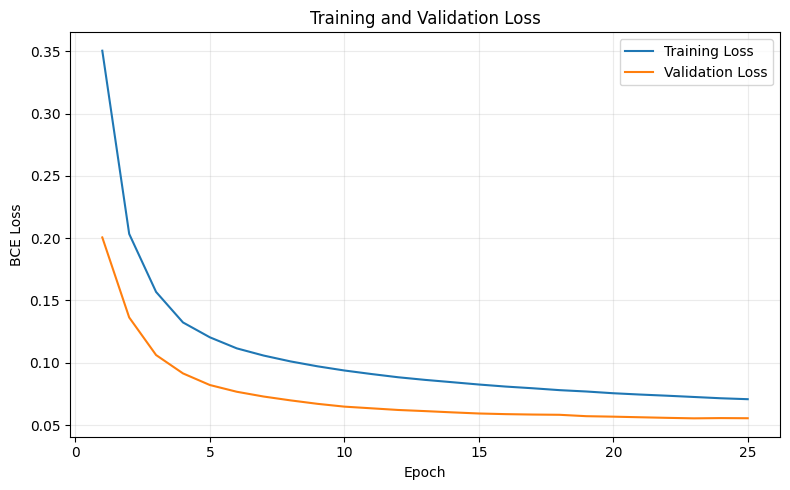

In [ ]:
epochs = range(1, EPOCHS + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, history["train_loss"], label="Training Loss")
plt.plot(epochs, history["validation_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("BCE Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()
plt.savefig("phase3_task1_learning_curves.png", dpi=180)
plt.show()


## 14. Load the best model and evaluate the test set

In [ ]:
model.load_state_dict(
    torch.load(checkpoint_path, map_location=DEVICE)
)
model.eval()

all_labels = []
all_probabilities = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(DEVICE)
        logits = model(features)
        probabilities = torch.sigmoid(logits)

        all_labels.extend(labels.numpy().reshape(-1))
        all_probabilities.extend(
            probabilities.cpu().numpy().reshape(-1)
        )

all_labels = np.array(all_labels)
all_probabilities = np.array(all_probabilities)
all_predictions = (all_probabilities >= 0.5).astype(int)

metrics = {
    "Accuracy": accuracy_score(all_labels, all_predictions),
    "Precision": precision_score(all_labels, all_predictions),
    "Recall": recall_score(all_labels, all_predictions),
    "F1-score": f1_score(all_labels, all_predictions),
    "ROC-AUC": roc_auc_score(all_labels, all_probabilities),
}

metrics_table = pd.DataFrame(
    {"Metric": metrics.keys(), "Value": metrics.values()}
)
display(metrics_table)

cm = confusion_matrix(all_labels, all_predictions)
print("Confusion matrix:")
print(cm)


,Metric,Value
0,Accuracy,0.982456
1,Precision,1.000000
2,Recall,0.952381
3,F1-score,0.975610
4,ROC-AUC,0.996693


Confusion matrix:
[[72  0]
 [ 2 40]]


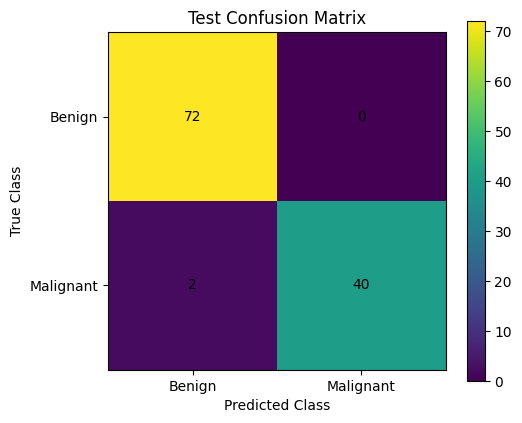

In [ ]:
plt.figure(figsize=(5.5, 4.5))
plt.imshow(cm)
plt.title("Test Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.xticks([0, 1], ["Benign", "Malignant"])
plt.yticks([0, 1], ["Benign", "Malignant"])

for row in range(cm.shape[0]):
    for column in range(cm.shape[1]):
        plt.text(column, row, cm[row, column], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.savefig("phase3_task1_confusion_matrix.png", dpi=180)
plt.show()


## 15. Key conclusions

- Tensors are the basic data structure used throughout PyTorch.
- Computational graphs record operations performed during the forward pass.
- Autograd calculates gradients automatically during backpropagation.
- A `Dataset` stores individual observations and labels.
- A `DataLoader` creates mini-batches and can shuffle training data.
- The typical PyTorch workflow is:

**Data → Dataset/DataLoader → Model → Loss Function → Optimizer → Training → Validation → Evaluation**

The next Phase 3 task can extend this notebook by replacing the simple linear classifier with a fully connected MLP and comparing different activations, optimizers, and regularization methods.

## Official learning resources

- PyTorch installation: https://pytorch.org/get-started/locally/
- PyTorch tensors: https://docs.pytorch.org/tutorials/beginner/basics/tensor_tutorial.html
- Autograd: https://docs.pytorch.org/tutorials/beginner/basics/autogradqs_tutorial.html
- Dataset and DataLoader: https://docs.pytorch.org/tutorials/beginner/basics/data_tutorial.html
- Breast Cancer Wisconsin dataset: https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html
